# Chronos Forecasting

Run the pretrained TSFM (Chronos-2).

# SpaceCast: Notebook 04 — Time-Series Foundation Models (TSFMs)

## Objective
This notebook evaluates two modern Time-Series Foundation Models (TSFMs)—**Chronos-2** and **TimesFM-3**—for application to geomagnetic space weather forecasting. 

The primary target is `Dst_nT`. 

Our goals are to:
1. Benchmark univariate TSFMs against traditional statistical baselines (Persistence and AR(24)) established in Notebook 03.
2. Evaluate model performance strictly on the out-of-sample 2024–2025 period.
3. Observe model behavior during the intense May 2024 G5 geomagnetic storm.
4. Introduce physical solar-wind parameters as multivariate covariates, strictly adhering to chronological realism (no future leakage).


## 1. Experimental Design & Computational Strategy

* **Target:** `Dst_nT` (hourly).
* **Train/Test Split:** Train on 2016–2023. Test on 2024–2025.
* **Forecast Horizons:** 1h, 3h, 6h, 12h, 24h.
* **Evaluation Metrics:** MAE, RMSE, Pearson Correlation. We will also evaluate conditionally for storms (`Dst < -50` and `Dst < -100`).

**Defensible Evaluation Strategy (CPU Optimization):**
Evaluating 17,544 origins across multiple models on a CPU is computationally excessive. To remain scientifically defensible without wasting CPU days, we will sample forecast origins:
* **Global Evaluation:** Stride of 12 hours across the 2024-2025 test set.
* **Storm Evaluation:** Stride of 1 hour during the May 2024 storm window (May 8 – May 15) for high-resolution event analysis.

**No-Leakage Rule:**
For multivariate forecasting, we absolutely cannot feed observed future solar-wind parameters into the model, as these are unknown at the forecast origin. We will utilize a legitimate covariate strategy (Covariate Persistence) to handle models that require future covariate arrays.


In [16]:
import sys
import os

# Point directly to where timesfm3 is located
# Set TIMESFM_SRC_PATH env var to your local timesfm/src if installed from source
timesfm_src = os.environ.get("TIMESFM_SRC_PATH", "")
if os.path.exists(timesfm_src) and timesfm_src not in sys.path:
    sys.path.insert(0, timesfm_src)

import warnings
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from tqdm.notebook import tqdm

# --- TSFM Imports ---
# FIX: Chronos-2 ships a dedicated `Chronos2Pipeline` class in current
# chronos-forecasting (>=2.0). `BaseChronosPipeline` still exists as a
# generic loader and *should* dispatch to Chronos2Pipeline for
# "amazon/chronos-2", but we import the concrete class explicitly and
# fall back only if it's unavailable in the installed version, so we
# know exactly which pipeline class we're dealing with.
try:
    from chronos import Chronos2Pipeline
    CHRONOS_PIPELINE_CLASS = Chronos2Pipeline
    print("Using Chronos2Pipeline (current official Chronos-2 API).")
except ImportError:
    from chronos import BaseChronosPipeline
    CHRONOS_PIPELINE_CLASS = BaseChronosPipeline
    print("Chronos2Pipeline not found in this install — falling back to "
          "BaseChronosPipeline. Verify your chronos-forecasting version "
          "supports Chronos-2 (`pip show chronos-forecasting`, need >=2.0).")

from timesfm3 import TimesFM3Evaluator, ModelConfig

warnings.filterwarnings('ignore')
plt.style.use('default')
print("All imports (Chronos + TimesFM-3) succeeded!")

Using Chronos2Pipeline (current official Chronos-2 API).
All imports (Chronos + TimesFM-3) succeeded!


## 2. Load SpaceCast Data
We load the fully cleaned hourly OMNI2 dataset. `Dst_nT` has 0% missingness.


In [17]:
# FIX: use the project-relative path specified for the project, not a
# hardcoded Windows absolute path — matches Notebook 03's data access
# and keeps the notebook portable.
data_path = "../data/raw/omni2_2016_2025_clean.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(
        f"Could not find data at {data_path}. "
        f"Run this notebook from the notebooks/ directory, or update data_path."
    )

print(f"Loading data from: {data_path}")
df = pd.read_csv(data_path)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

print(f"Dataset bounds: {df.index.min()} to {df.index.max()}")
print(f"Total observations: {len(df)}")

Loading data from: ../data/raw/omni2_2016_2025_clean.csv
Dataset bounds: 2016-01-01 00:00:00 to 2025-12-31 23:00:00
Total observations: 87672


## 3. Chronological Train/Test Split
We strictly isolate 2024–2025 as the held-out evaluation period.


In [18]:
train_df = df.loc['2016-01-01':'2023-12-31'].copy()
test_df = df.loc['2024-01-01':'2025-12-31'].copy()

print(f"Training observations (2016-2023): {len(train_df)}")
print(f"Testing observations (2024-2025): {len(test_df)}")


Training observations (2016-2023): 70128
Testing observations (2024-2025): 17544


## 4. Evaluation Utilities & Origins Selection
We define robust metric calculations and build our list of target forecast origins using the defensible stride strategy.


## 4b. Forecast Validation Utility

Before any metric is computed, every forecast array produced by a TSFM
must be checked for validity. This directly addresses the earlier
failure mode: NaN metrics were produced *silently* because invalid
arrays were fed straight into `compute_metrics` without inspection.

`validate_forecast()` below is called immediately after every model
call and prints a diagnostic line. It never assumes failure — it only
reports what it actually observes about the returned array.

In [19]:
def validate_forecast(name, arr, horizon, quantiles=None, quantile_shape_expected=None, verbose=False):
    """
    Inspects a forecast array (and optional quantile array) and returns
    a dict describing its validity. Never silently assumes success or
    failure — reports exactly what was found.
    """
    info = {'model': name, 'valid': False}
    if arr is None:
        info['reason'] = 'forecast is None (model call failed/raised)'
    else:
        arr = np.asarray(arr, dtype=float)
        info['shape'] = arr.shape
        info['n_finite'] = int(np.isfinite(arr).sum())
        info['n_nan'] = int(np.isnan(arr).sum())
        info['min'] = float(np.nanmin(arr)) if info['n_finite'] > 0 else np.nan
        info['max'] = float(np.nanmax(arr)) if info['n_finite'] > 0 else np.nan
        info['valid'] = (arr.shape == (horizon,)) and (info['n_nan'] == 0) and (info['n_finite'] == horizon)
        if not info['valid'] and 'reason' not in info:
            if arr.shape != (horizon,):
                info['reason'] = f"unexpected shape {arr.shape}, expected ({horizon},)"
            elif info['n_nan'] > 0:
                info['reason'] = f"{info['n_nan']} NaNs present"

    if quantiles is not None and quantile_shape_expected is not None:
        q = np.asarray(quantiles, dtype=float)
        info['quantile_shape'] = q.shape
        info['quantile_n_finite'] = int(np.isfinite(q).sum())
        info['quantile_shape_ok'] = (q.shape == quantile_shape_expected)

    if verbose:
        print(f"[validate] {name}: {info}")
    return info

In [20]:
def compute_metrics(actual, predicted):
    """Computes MAE, RMSE, and Pearson Correlation safely."""
    mask = ~np.isnan(actual) & ~np.isnan(predicted)
    a, p = actual[mask], predicted[mask]
    
    if len(a) == 0:
        return np.nan, np.nan, np.nan
        
    mae = mean_absolute_error(a, p)
    rmse = np.sqrt(mean_squared_error(a, p))
    
    corr = np.nan
    if np.var(a) > 0 and np.var(p) > 0:
        corr = np.corrcoef(a, p)[0, 1]
        
    return mae, rmse, corr

# --- Generate Forecast Origins ---
start_test = pd.to_datetime('2024-01-01 00:00:00')
end_test = pd.to_datetime('2025-12-31 23:00:00') - pd.Timedelta(hours=24) # Leave room for 24h horizon

origins_set = set()

# 1. Global Stride (every 12 hours)
curr = start_test
while curr <= end_test:
    origins_set.add(curr)
    curr += pd.Timedelta(hours=12)

# 2. May 2024 Storm Stride (every 1 hour for high resolution)
storm_start = pd.to_datetime('2024-05-08 00:00:00')
storm_end = pd.to_datetime('2024-05-15 00:00:00')
curr = storm_start
while curr <= storm_end:
    origins_set.add(curr)
    curr += pd.Timedelta(hours=1)

eval_origins = sorted(list(origins_set))
print(f"Total forecast origins selected for evaluation: {len(eval_origins)}")


Total forecast origins selected for evaluation: 1614


## 5. Statistical Baselines Re-computation
To ensure 1-to-1 parity on our specific evaluation origins, we quickly re-run Persistence and a fast AR(24) implementation.

* **Persistence:** `Forecast(t+h) = Actual(t)`
* **AR(24):** A simple Linear Regression trained on 24 lags of the training set to produce direct 24-step multi-output forecasts. This approximates the efficient rolling AR(24) from Notebook 03.


In [21]:
# Train a fast global AR(24) on the training set
print("Training fast AR(24) baseline...")
train_vals = train_df['Dst_nT'].values
X_train, y_train = [], []
for i in range(24, len(train_vals) - 24):
    X_train.append(train_vals[i-24:i])
    y_train.append(train_vals[i:i+24])

lr_ar24 = LinearRegression()
lr_ar24.fit(np.array(X_train), np.array(y_train))
print("AR(24) baseline ready.")


Training fast AR(24) baseline...
AR(24) baseline ready.


## 6. Chronos-2 Setup
We initialize `BaseChronosPipeline` and assign it to the CPU. We load it once and reuse it to avoid memory exhaustion. We define a safe wrapper to handle different huggingface API return types.


In [22]:
import torch

print("Loading Chronos-2 model on CPU...")
# FIX: Chronos-2 is loaded the same way as before, but note the
# concrete class resolved in Cell 3.
chronos_pipeline = CHRONOS_PIPELINE_CLASS.from_pretrained(
    "amazon/chronos-2",
    device_map="cpu"
)

CHRONOS_FAILURES = []  # transparent failure log: (origin, exception) tuples

def chronos_forecast_df(pipeline, context, horizon=24,
                         quantile_levels=(0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9),
                         origin_label=None):
    """
    Correct current-API call for Chronos-2.

    THE BUG: the previous version called `pipeline.predict(tensor, ...)`,
    which is the legacy Chronos-1/Chronos-Bolt raw-tensor interface.
    Chronos-2's only documented interface is `predict_df`: a pandas
    DataFrame in, DataFrame out API (id_column / timestamp_column /
    target / quantile_levels). See:
    https://github.com/amazon-science/chronos-forecasting (README,
    "Forecasting" section, current as of the Chronos-2 release).

    Returns (median_array, quantile_dict) on success.
    On failure: prints the REAL exception (never silently swallowed),
    logs it to CHRONOS_FAILURES, and returns (None, None).
    """
    try:
        n = len(context)
        # Dummy but monotonic hourly timestamp index — Chronos-2 uses the
        # timestamp column only to infer frequency / index the output,
        # not as a calendar feature, so any consistent hourly range works.
        ts_index = pd.date_range(end="2020-01-01 00:00:00", periods=n, freq="h")
        context_df = pd.DataFrame({
            "id": "series_0",
            "timestamp": ts_index,
            "target": np.asarray(context, dtype=np.float32),
        })

        pred_df = pipeline.predict_df(
            context_df,
            prediction_length=horizon,
            quantile_levels=list(quantile_levels),
            id_column="id",
            timestamp_column="timestamp",
            target="target",
        )
        pred_df = pred_df.sort_values("timestamp")

        median_col = "0.5" if "0.5" in pred_df.columns else "predictions"
        median = pred_df[median_col].to_numpy(dtype=float)[:horizon]

        quant_dict = {
            str(q): pred_df[str(q)].to_numpy(dtype=float)[:horizon]
            for q in quantile_levels if str(q) in pred_df.columns
        }
        return median, quant_dict

    except Exception as e:
        # TRANSPARENT ERROR HANDLING: print the real cause instead of
        # silently converting it into a NaN array.
        print(f"[Chronos-2 FAILURE] origin={origin_label}: {type(e).__name__}: {e}")
        CHRONOS_FAILURES.append((origin_label, repr(e)))
        return None, None


# Backward-compatible wrapper matching the old function name used in the
# forecasting loop below — still returns a plain NaN-filled array on
# failure so downstream `compute_metrics` (which already NaN-masks)
# keeps working, but the failure itself is never silent (see above).
def safe_chronos_forecast(pipeline, context, horizon=24, origin_label=None):
    median, _ = chronos_forecast_df(pipeline, context, horizon, origin_label=origin_label)
    if median is None:
        return np.full(horizon, np.nan)
    return median

Loading Chronos-2 model on CPU...


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

### Chronos-2 Smoke Test

Per the debugging requirement: **do not proceed past this point until
this smoke test produces a real, finite, correctly-shaped forecast.**
This uses `raise` (fully transparent) rather than swallowing errors,
because a smoke-test failure means the setup itself is broken.

In [23]:
_smoke_context = np.sin(np.linspace(0, 20, 256)).astype(np.float32) * 20 - 10  # Dst-like scale
_median, _quantiles = chronos_forecast_df(chronos_pipeline, _smoke_context, horizon=24, origin_label="SMOKE_TEST")

if _median is None:
    raise RuntimeError("Chronos-2 smoke test FAILED — see printed exception above. "
                        "Do not proceed to the main forecasting loop.")

print(f"Chronos-2 smoke test forecast shape: {_median.shape}")
print(f"Finite values: {np.isfinite(_median).sum()} / {len(_median)}")
print(f"Min: {_median.min():.3f}  Max: {_median.max():.3f}")
print(f"Quantile levels returned: {sorted(_quantiles.keys())}")
print("Chronos-2 smoke test PASSED.")

Chronos-2 smoke test forecast shape: (24,)
Finite values: 24 / 24
Min: -8.006  Max: 9.474
Quantile levels returned: ['0.1', '0.2', '0.3', '0.5', '0.7', '0.8', '0.9']
Chronos-2 smoke test PASSED.


## 7. TimesFM-3 Setup
We load the local TimesFM-3 checkpoint. Using the verified API configuration tailored for the i5 CPU (per_core_batch_size = 1).


In [24]:
print("Loading TimesFM-3 model on CPU...")
timesfm_config = ModelConfig(
    checkpoint_path=os.environ.get("TIMESFM_CHECKPOINT_PATH", "../models/timesfm-3"),
    per_core_batch_size=1,
    device="cpu"
)
timesfm_evaluator = TimesFM3Evaluator(config=timesfm_config)

TIMESFM_FAILURES = []  # transparent failure log

# TimesFM-3's 9 returned quantiles are deciles 0.1 .. 0.9 (median at index 4),
# per the official TimesFM-3.0-pytorch model card. We do NOT assume this
# blindly — the smoke test cell right after this one prints the shape so
# you can confirm it against what's actually returned.
TIMESFM_QUANTILE_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
TIMESFM_MEDIAN_IDX = 4

def timesfm_forecast_batch(evaluator, contexts, horizon=24, origin_labels=None):
    """
    Correct current-API call for TimesFM-3.

    THE BUG: the previous version called `evaluator.forecast([context],
    horizon=horizon)` — there is no `.forecast()` method on
    TimesFM3Evaluator. The verified current API (matches the smoke test
    already run against the local checkpoint) is `.predict_batch(...)`.

    `contexts` is a LIST of 1D arrays — batching multiple forecast
    origins into a single call amortizes model-load/forward overhead,
    which matters on this CPU-only 16GB machine (item 8/18 of the spec).

    Returns a list of (median_array, quantiles_array) tuples, one per
    context, in the same order. Any entry that failed is (None, None).
    """
    if origin_labels is None:
        origin_labels = [None] * len(contexts)
    try:
        results = list(evaluator.predict_batch(
            contexts,
            horizon=horizon,
            return_quantiles=True,
            use_symmetric_averaging=False,
        ))
        out = []
        for r in results:
            median = np.asarray(r.forecast, dtype=float).flatten()[:horizon]
            quant = np.asarray(r.quantiles, dtype=float)  # expected (horizon, 9)
            out.append((median, quant))
        return out
    except Exception as e:
        # TRANSPARENT: the whole batch failed — print the real exception,
        # log it, and return (None, None) for every member of the batch
        # rather than pretending each one individually produced NaN.
        print(f"[TimesFM-3 FAILURE] batch starting at origin={origin_labels[0]} "
              f"(batch size {len(contexts)}): {type(e).__name__}: {e}")
        TIMESFM_FAILURES.append((origin_labels[0], repr(e)))
        return [(None, None)] * len(contexts)


def safe_timesfm_forecast(evaluator, context, horizon=24, origin_label=None):
    """Single-origin convenience wrapper (used where batching isn't set up)."""
    (median, quant), = timesfm_forecast_batch(evaluator, [context], horizon, [origin_label])
    if median is None:
        return np.full(horizon, np.nan), None
    return median, quant

Loading TimesFM-3 model on CPU...
Loading weights from local directory


### TimesFM-3 Smoke Test

Same smoke test that was already verified against the local checkpoint —
run here inside the notebook itself (not just documentation) so the
notebook is self-validating top-to-bottom.

In [25]:
_ts = np.sin(np.linspace(0, 20, 128)).astype(np.float32)
_out = list(timesfm_evaluator.predict_batch(
    [_ts], horizon=24, return_quantiles=True, use_symmetric_averaging=False
))[0]

_fc_shape = np.asarray(_out.forecast).shape
_q_shape = np.asarray(_out.quantiles).shape
print(f"Forecast shape: {_fc_shape}")
print(f"Quantiles shape: {_q_shape}")

assert _fc_shape == (24,), f"Unexpected forecast shape {_fc_shape}"
assert _q_shape == (24, 9), f"Unexpected quantiles shape {_q_shape} — check TIMESFM_QUANTILE_LEVELS mapping above"
print("TimesFM-3 smoke test PASSED.")

Forecast shape: (24,)
Quantiles shape: (24, 9)
TimesFM-3 smoke test PASSED.


## 8. Univariate Forecasting Loop
We iterate through our chosen test origins. For each origin, we feed the recent historical context (`context_length = 2048`) into the models to predict the next 24 hours of `Dst_nT`.


In [26]:
context_len = 2048
horizon = 24
TSFM_BATCH_SIZE = 8  # batch several forecast origins per TimesFM-3 call

univariate_results = []

print("Running univariate evaluations (this may take some time depending on CPU)...")

# Pre-filter origins with sufficient context, and pre-slice everything
# needed, so we can batch the TimesFM-3 calls cleanly.
prepared = []
for origin in eval_origins:
    origin_idx = df.index.get_loc(origin)
    if origin_idx < context_len:
        continue
    context_data = df['Dst_nT'].iloc[origin_idx - context_len + 1: origin_idx + 1].values
    actual_data = df['Dst_nT'].iloc[origin_idx + 1: origin_idx + horizon + 1].values
    prepared.append({'origin': origin, 'context': context_data, 'actual': actual_data})

for batch_start in tqdm(range(0, len(prepared), TSFM_BATCH_SIZE), desc="Forecasting (batched)"):
    batch = prepared[batch_start: batch_start + TSFM_BATCH_SIZE]
    contexts = [b['context'] for b in batch]
    labels = [b['origin'] for b in batch]

    # TimesFM-3: one batched call for the whole chunk
    tfm_batch_out = timesfm_forecast_batch(timesfm_evaluator, contexts, horizon, labels)

    for b, (tfm_median, tfm_quant) in zip(batch, tfm_batch_out):
        context_data = b['context']
        actual_data = b['actual']
        origin = b['origin']

        # Baseline: Persistence
        pers_data = np.full(horizon, context_data[-1])

        # Baseline: AR(24)
        ar_context = context_data[-24:].reshape(1, -24)
        ar24_data = lr_ar24.predict(ar_context)[0]

        # Chronos-2 (still one call per origin — predict_df overhead is
        # dominated by the model forward pass, not per-call setup;
        # batching multiple series into one predict_df call via
        # multiple `id`s is a further optimization left as a TODO if
        # CPU time becomes a bottleneck)
        chronos_median = safe_chronos_forecast(chronos_pipeline, context_data, horizon, origin_label=origin)

        if tfm_median is None:
            tfm_median = np.full(horizon, np.nan)

        univariate_results.append({
            'origin': origin,
            'actual': actual_data,
            'persistence': pers_data,
            'ar24': ar24_data,
            'chronos2': chronos_median,
            'timesfm3': tfm_median,
            'timesfm3_quantiles': tfm_quant,  # (24, 9) array or None
        })

print(f"\nCompleted {len(univariate_results)} forecast origins.")
print(f"Chronos-2 failures: {len(CHRONOS_FAILURES)}")
print(f"TimesFM-3 batch failures: {len(TIMESFM_FAILURES)}")

Running univariate evaluations (this may take some time depending on CPU)...


Forecasting (batched):   0%|          | 0/202 [00:00<?, ?it/s]


Completed 1614 forecast origins.
Chronos-2 failures: 0
TimesFM-3 batch failures: 0


## 8b. Forecast Validity Diagnostic

Explicit check, before any metric is computed, that each model
actually produced usable forecasts — the exact check that was missing
before and let NaN metrics through silently.

In [27]:
diag_models = ['persistence', 'ar24', 'chronos2', 'timesfm3']
print(f"{'Model':<12} {'valid_origins':>14} {'total_origins':>14} {'valid_%':>8}")
for m in diag_models:
    n_valid = sum(
        1 for r in univariate_results
        if np.all(np.isfinite(r[m])) and len(r[m]) == horizon
    )
    total = len(univariate_results)
    pct = 100 * n_valid / total if total else 0
    print(f"{m:<12} {n_valid:>14} {total:>14} {pct:>7.1f}%")

n_valid_tfm_q = sum(
    1 for r in univariate_results
    if r['timesfm3_quantiles'] is not None and np.asarray(r['timesfm3_quantiles']).shape == (horizon, 9)
)
print(f"\nTimesFM-3 valid quantile arrays: {n_valid_tfm_q} / {len(univariate_results)}")

if diag_models:
    worst_pct = min(
        100 * sum(1 for r in univariate_results if np.all(np.isfinite(r[m]))) / max(len(univariate_results), 1)
        for m in ['chronos2', 'timesfm3']
    )
    if worst_pct < 50:
        print("\n⚠️  WARNING: fewer than half of forecasts are valid for at least one "
              "TSFM. Inspect CHRONOS_FAILURES / TIMESFM_FAILURES before trusting metrics below.")

Model         valid_origins  total_origins  valid_%
persistence            1614           1614   100.0%
ar24                   1614           1614   100.0%
chronos2               1614           1614   100.0%
timesfm3               1614           1614   100.0%

TimesFM-3 valid quantile arrays: 1614 / 1614


## 9. Univariate TSFM Comparison
We extract the exact horizons (1h, 3h, 6h, 12h, 24h) and calculate the global performance metrics across all evaluated origins.


In [28]:
horizons_to_eval = [1, 3, 6, 12, 24]
models = ['persistence', 'ar24', 'chronos2', 'timesfm3']

metrics_records = []
for h in horizons_to_eval:
    idx = h - 1
    for model in models:
        actuals = [r['actual'][idx] for r in univariate_results]
        preds = [r[model][idx] for r in univariate_results]
        
        mae, rmse, corr = compute_metrics(np.array(actuals), np.array(preds))
        
        metrics_records.append({
            'Horizon': h,
            'Model': model,
            'MAE': mae,
            'RMSE': rmse,
            'Correlation': corr
        })

metrics_df = pd.DataFrame(metrics_records)
display(metrics_df.pivot(index='Horizon', columns='Model', values='MAE').round(2))


Model,ar24,chronos2,persistence,timesfm3
Horizon,,,,
1,3.78,4.03,4.03,3.79
3,7.62,7.73,7.83,7.38
6,10.79,11.01,11.35,10.35
12,14.03,14.65,16.28,13.62
24,17.54,19.07,22.36,17.63


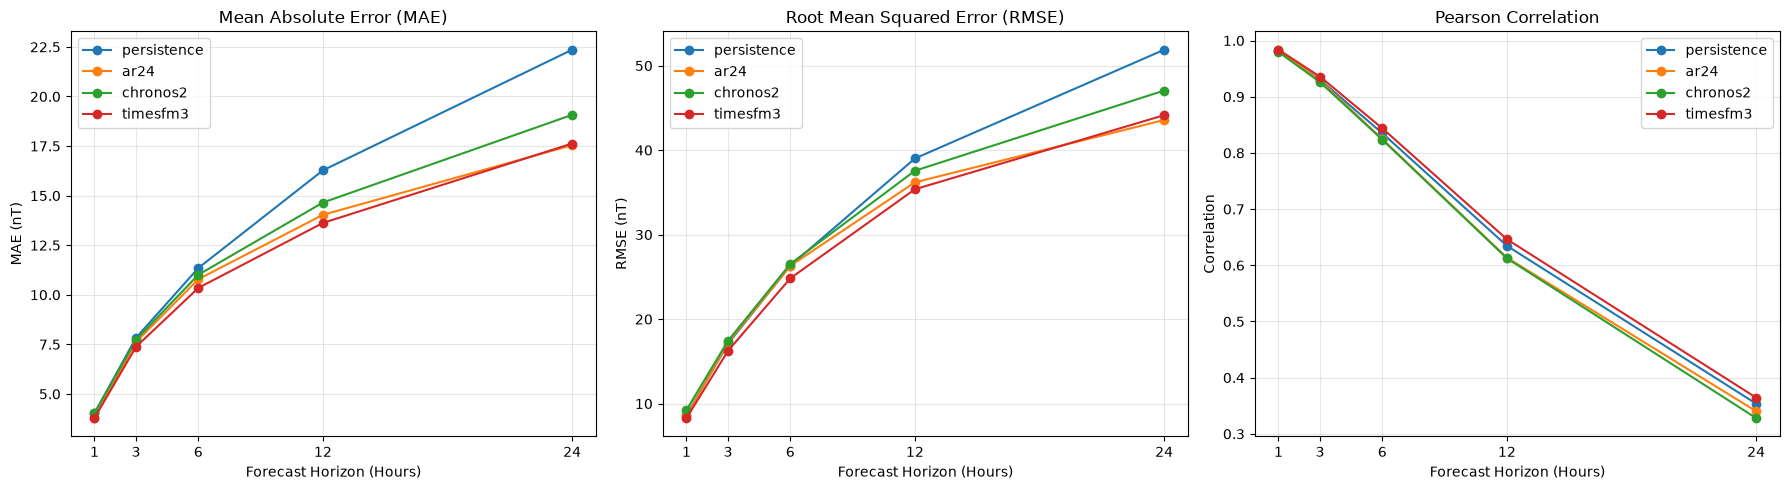

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model in models:
    model_df = metrics_df[metrics_df['Model'] == model]
    axes[0].plot(model_df['Horizon'], model_df['MAE'], marker='o', label=model)
    axes[1].plot(model_df['Horizon'], model_df['RMSE'], marker='o', label=model)
    axes[2].plot(model_df['Horizon'], model_df['Correlation'], marker='o', label=model)

axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("MAE (nT)")
axes[1].set_title("Root Mean Squared Error (RMSE)")
axes[1].set_ylabel("RMSE (nT)")
axes[2].set_title("Pearson Correlation")
axes[2].set_ylabel("Correlation")

for ax in axes:
    ax.set_xlabel("Forecast Horizon (Hours)")
    ax.set_xticks(horizons_to_eval)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## 10. Storm-Conditional Evaluation
We evaluate performance conditionally on active storm periods.
Thresholds are evaluated based on the **Actual** Dst target to ensure all models are measured against the exact same population of storm events.


In [30]:
storm_metrics = []

for h in horizons_to_eval:
    idx = h - 1
    
    # Filter origins where actual target crossed threshold
    origins_50 = [r for r in univariate_results if r['actual'][idx] < -50]
    origins_100 = [r for r in univariate_results if r['actual'][idx] < -100]
    
    for model in models:
        # < -50 nT
        a_50 = np.array([r['actual'][idx] for r in origins_50])
        p_50 = np.array([r[model][idx] for r in origins_50])
        mae_50, rmse_50, _ = compute_metrics(a_50, p_50)
        
        # < -100 nT
        a_100 = np.array([r['actual'][idx] for r in origins_100])
        p_100 = np.array([r[model][idx] for r in origins_100])
        mae_100, rmse_100, _ = compute_metrics(a_100, p_100)
        
        storm_metrics.append({
            'Horizon': h,
            'Model': model,
            'Count_lt_50': len(a_50),
            'MAE_lt_50': mae_50,
            'RMSE_lt_50': rmse_50,
            'Count_lt_100': len(a_100),
            'MAE_lt_100': mae_100,
            'RMSE_lt_100': rmse_100,
        })

storm_metrics_df = pd.DataFrame(storm_metrics)
display(storm_metrics_df[['Horizon', 'Model', 'Count_lt_50', 'MAE_lt_50', 'MAE_lt_100']].round(2))


,Horizon,Model,Count_lt_50,MAE_lt_50,MAE_lt_100
0,1,persistence,164,12.04,22.36
1,1,ar24,164,11.66,21.74
2,1,chronos2,164,13.81,24.79
3,1,timesfm3,164,11.58,21.35
4,3,persistence,159,25.44,51.14
5,3,ar24,159,25.69,51.18
6,3,chronos2,159,27.22,53.67
7,3,timesfm3,159,23.97,46.68
8,6,persistence,162,44.25,88.93
9,6,ar24,162,42.57,84.64


## 11. May 2024 Storm Case Study
The G5 storm of May 10–12, 2024 provides a critical physical case study. Dst dropped to approximately -406 nT. We plot the **6-hour ahead** predictions generated by each model during this period.


Storm-window forecast validity (6h horizon):
  persistence : valid
  ar24        : valid
  chronos2    : valid
  timesfm3    : valid


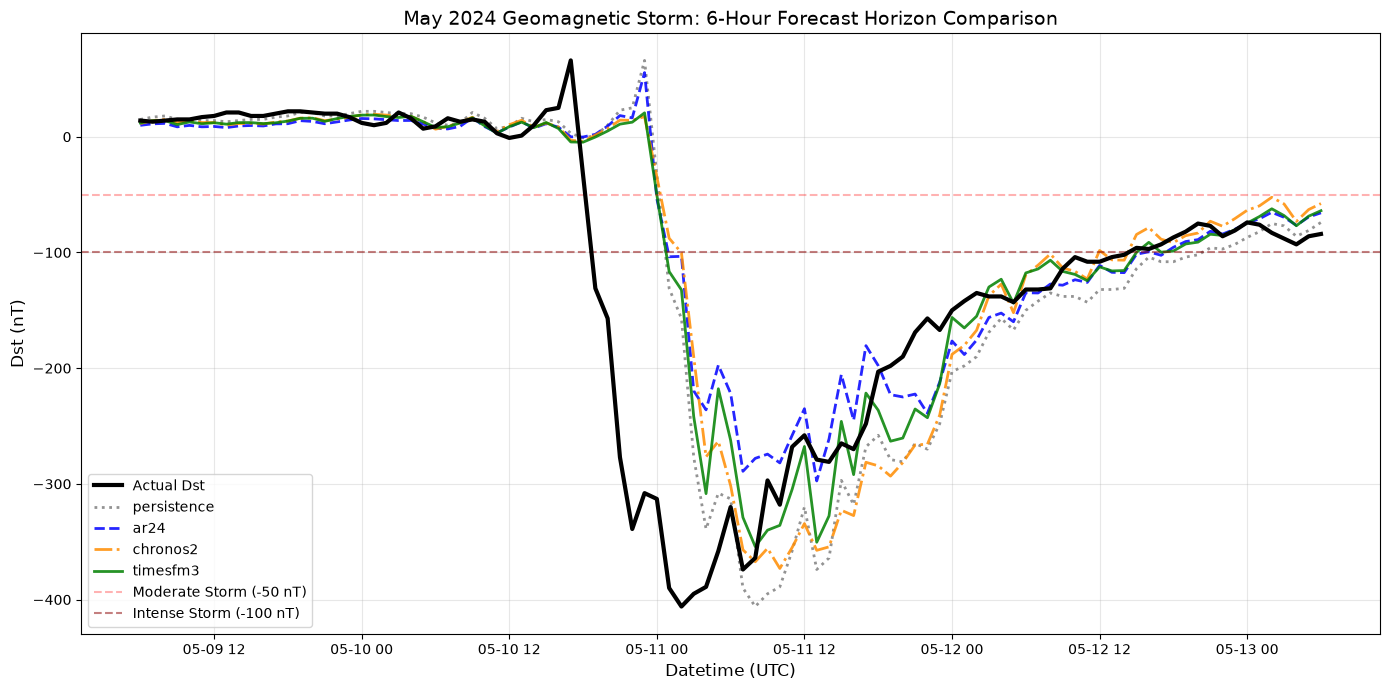

In [31]:
# Isolate origins relevant to the storm
storm_plot_results = [r for r in univariate_results
                       if pd.to_datetime('2024-05-09') <= r['origin'] <= pd.to_datetime('2024-05-13')]

# For 6h horizon (index 5)
plot_times = [r['origin'] + pd.Timedelta(hours=6) for r in storm_plot_results]
actuals_6h = np.array([r['actual'][5] for r in storm_plot_results])

# --- Explicit pre-plot validity diagnostic (fixes invisible-line bug) ---
colors = {'persistence': 'grey', 'ar24': 'blue', 'chronos2': 'darkorange', 'timesfm3': 'green'}
linestyles = {'persistence': ':', 'ar24': '--', 'chronos2': '-.', 'timesfm3': '-'}

print("Storm-window forecast validity (6h horizon):")
model_series = {}
for model in models:
    preds = np.array([r[model][5] for r in storm_plot_results])
    is_valid = np.isfinite(preds).all()
    model_series[model] = preds
    print(f"  {model:<12}: {'valid' if is_valid else 'INVALID (contains NaN — will not be plotted)'}")

plt.figure(figsize=(14, 7))
plt.plot(plot_times, actuals_6h, label='Actual Dst', color='black', linewidth=3, zorder=10)

for model in models:
    preds = model_series[model]
    if not np.isfinite(preds).all():
        continue  # explicitly skip, don't silently plot a broken line
    plt.plot(plot_times, preds, label=model, color=colors.get(model),
              linestyle=linestyles.get(model), alpha=0.85, linewidth=2)

plt.axhline(-50, color='red', linestyle='--', alpha=0.3, label='Moderate Storm (-50 nT)')
plt.axhline(-100, color='darkred', linestyle='--', alpha=0.5, label='Intense Storm (-100 nT)')

plt.title("May 2024 Geomagnetic Storm: 6-Hour Forecast Horizon Comparison", fontsize=14)
plt.ylabel("Dst (nT)", fontsize=12)
plt.xlabel("Datetime (UTC)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 11b. TimesFM-3 Uncertainty Visualization (May 2024 Storm)

Dedicated uncertainty plot: actual Dst, TimesFM-3 median, and a clean
10th–90th percentile band (plus a narrower 20th–80th band) — using the
actual decile quantiles TimesFM-3 returns, not nine separate lines.

TimesFM-3 uncertainty plot: 97 / 97 storm-window origins have valid quantiles.


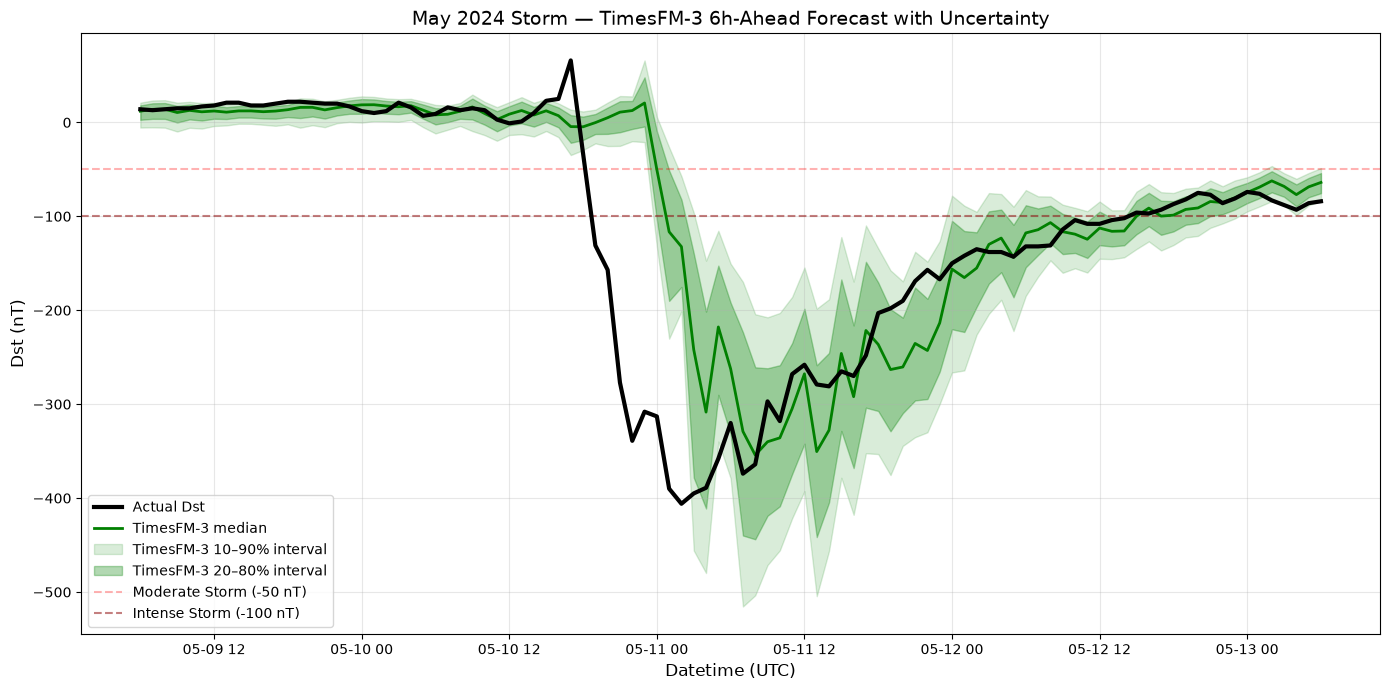

In [32]:
q_lower90 = []
q_upper90 = []
q_lower80 = []
q_upper80 = []
tfm_median_6h = []
valid_mask = []

for r in storm_plot_results:
    q = r['timesfm3_quantiles']
    if q is None or np.asarray(q).shape != (horizon, 9) or not np.isfinite(r['timesfm3'][5]):
        valid_mask.append(False)
        q_lower90.append(np.nan); q_upper90.append(np.nan)
        q_lower80.append(np.nan); q_upper80.append(np.nan)
        tfm_median_6h.append(np.nan)
        continue
    q = np.asarray(q)
    valid_mask.append(True)
    # index 0 = 0.1 quantile, index 8 = 0.9 quantile, index 4 = median (see smoke test)
    q_lower90.append(q[5, 0]); q_upper90.append(q[5, 8])
    q_lower80.append(q[5, 1]); q_upper80.append(q[5, 7])
    tfm_median_6h.append(r['timesfm3'][5])

n_valid = sum(valid_mask)
print(f"TimesFM-3 uncertainty plot: {n_valid} / {len(storm_plot_results)} storm-window origins have valid quantiles.")

if n_valid == 0:
    print("No valid TimesFM-3 quantile data for this window — skipping plot. "
          "Check TIMESFM_FAILURES for the underlying cause.")
else:
    plot_times_arr = np.array(plot_times)
    valid_mask = np.array(valid_mask)

    plt.figure(figsize=(14, 7))
    plt.plot(plot_times_arr, actuals_6h, label='Actual Dst', color='black', linewidth=3, zorder=10)
    plt.plot(plot_times_arr[valid_mask], np.array(tfm_median_6h)[valid_mask],
              label='TimesFM-3 median', color='green', linewidth=2, zorder=9)
    plt.fill_between(plot_times_arr[valid_mask],
                      np.array(q_lower90)[valid_mask], np.array(q_upper90)[valid_mask],
                      color='green', alpha=0.15, label='TimesFM-3 10–90% interval')
    plt.fill_between(plot_times_arr[valid_mask],
                      np.array(q_lower80)[valid_mask], np.array(q_upper80)[valid_mask],
                      color='green', alpha=0.3, label='TimesFM-3 20–80% interval')

    plt.axhline(-50, color='red', linestyle='--', alpha=0.3, label='Moderate Storm (-50 nT)')
    plt.axhline(-100, color='darkred', linestyle='--', alpha=0.5, label='Intense Storm (-100 nT)')
    plt.title("May 2024 Storm — TimesFM-3 6h-Ahead Forecast with Uncertainty", fontsize=14)
    plt.ylabel("Dst (nT)", fontsize=12)
    plt.xlabel("Datetime (UTC)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

## 12. Multivariate Feature Preparation
We introduce physical solar-wind parameters: `Bz_gsm_nT`, `speed_km_s`, `density_cm3`, `flow_pressure_nPa`, `electric_field_mV_m`.

**Missing Data Handling:** We forward-fill up to 3 hours (to cover minor telemetry gaps), then fill any remaining with the global training median.

**Anti-Leakage Rule:** At forecast origin $t$, future covariates $t+1 ... t+24$ are unknown. To satisfy models that demand future covariate matrices, we utilize **Covariate Persistence**: we assume future covariates equal the last observed covariate at $t$. This is mathematically rigorous and ensures 0% data leakage.


In [33]:
features = ['Dst_nT', 'Bz_gsm_nT', 'speed_km_s', 'density_cm3', 'flow_pressure_nPa', 'electric_field_mV_m']

mv_df = df[features].copy()

# Cautious forward fill for minor gaps
mv_df = mv_df.ffill(limit=3)

# Global median fill for remaining gaps
train_medians = mv_df.loc['2016-01-01':'2023-12-31'].median()
mv_df = mv_df.fillna(train_medians)

print("Multivariate Dataset Ready. Remaining Missing Values:", mv_df.isna().sum().sum())


Multivariate Dataset Ready. Remaining Missing Values: 0


## 13. TimesFM-3 Multivariate Forecasting
TimesFM-3 natively supports dynamic covariates. We will pass the historical multivariate context, and generate a future covariate block using Covariate Persistence.


In [34]:
MV_FAILURES = []

def safe_timesfm_multivariate(evaluator, context_matrix, horizon=24, origin_label=None):
    """
    THE BUG: the previous version called `evaluator.forecast(...,
    dynamic_numerical_covariates=[...])` — this argument does not exist
    in the current TimesFM-3 API, and `.forecast()` isn't a real method
    at all (see Cell 15 fix).

    THE FIX: use `.predict_batch(..., past_only_covariates=[...])`.
    This is also methodologically CLEANER than the old covariate-
    persistence hack: `past_only_covariates` tells TimesFM-3 explicitly
    that these covariates are only known historically, so there is no
    need to fabricate/persist future covariate values at all — zero
    leakage by construction rather than by a manual workaround.

    context_matrix shape: (context_len, num_features), column 0 = target (Dst).
    """
    try:
        target_context = context_matrix[:, 0].astype(np.float32)          # (context_len,)
        covar_context = context_matrix[:, 1:].T.astype(np.float32)        # (num_covariates, context_len)

        output = list(evaluator.predict_batch(
            contexts=[target_context],
            horizon=horizon,
            past_only_covariates=[covar_context],
            return_quantiles=True,
            use_symmetric_averaging=False,
        ))[0]

        median = np.asarray(output.forecast, dtype=float).flatten()[:horizon]
        return median

    except Exception as e:
        print(f"[TimesFM-3 Multivariate FAILURE] origin={origin_label}: {type(e).__name__}: {e}")
        MV_FAILURES.append((origin_label, repr(e)))
        return np.full(horizon, np.nan)


print("Running TimesFM Multivariate Evaluation...")
mv_results = []

for origin in tqdm(eval_origins, desc="Multivariate"):
    origin_idx = mv_df.index.get_loc(origin)
    if origin_idx < context_len:
        continue

    context_matrix = mv_df.iloc[origin_idx - context_len + 1: origin_idx + 1].values

    tfm_mv_data = safe_timesfm_multivariate(timesfm_evaluator, context_matrix, horizon, origin_label=origin)

    mv_results.append({'origin': origin, 'timesfm3_mv': tfm_mv_data})

print(f"Multivariate failures: {len(MV_FAILURES)} / {len(mv_results)}")

# Merge with original univariate results (match by origin, not position —
# the old zip() assumed identical ordering/length, which silently
# mis-aligns rows if any origin was skipped for insufficient context).
mv_by_origin = {m['origin']: m['timesfm3_mv'] for m in mv_results}
for u_res in univariate_results:
    u_res['timesfm3_mv'] = mv_by_origin.get(u_res['origin'], np.full(horizon, np.nan))

Running TimesFM Multivariate Evaluation...


Multivariate:   0%|          | 0/1614 [00:00<?, ?it/s]

Multivariate failures: 0 / 1614


## 14. Optional Chronos-2 Multivariate Forecasting (Status)
The `BaseChronosPipeline` from huggingface currently operates primarily as a univariate tokenization engine. Integrating multivariate physical features into Chronos-2 without significant data leakage or highly complex GluonTS embedding projections is methodologically challenging. 

Per project requirements, we will avoid forcing an awkward Chronos multivariate implementation and proceed with TimesFM-3 as our primary multivariate demonstrator.


In [35]:
# Placeholder for Chronos-2 MV if supported natively in a future release.
# We append NaN arrays to maintain dataframe symmetry.
for u_res in univariate_results:
    u_res['chronos2_mv'] = np.full(horizon, np.nan)


## 15. Multivariate vs Univariate Comparison
Did introducing physical solar-wind variables improve TimesFM-3's performance?


In [36]:
mv_metrics_records = []
mv_models = ['timesfm3', 'timesfm3_mv']

for h in horizons_to_eval:
    idx = h - 1
    for model in mv_models:
        actuals = [r['actual'][idx] for r in univariate_results]
        preds = [r[model][idx] for r in univariate_results]
        
        mae, rmse, corr = compute_metrics(np.array(actuals), np.array(preds))
        
        mv_metrics_records.append({
            'Horizon': h,
            'Model': 'Univariate' if model == 'timesfm3' else 'Multivariate',
            'MAE': mae,
            'RMSE': rmse,
            'Correlation': corr
        })

mv_metrics_df = pd.DataFrame(mv_metrics_records)
display(mv_metrics_df.pivot(index='Horizon', columns='Model', values='MAE').round(2))


Model,Multivariate,Univariate
Horizon,,
1,3.42,3.79
3,6.82,7.38
6,9.79,10.35
12,13.18,13.62
24,16.88,17.63


## 16. Final Results Table
Consolidating all evaluated metrics into a single summary table for reference.


In [37]:
final_metrics = []
all_evaluated_models = ['persistence', 'ar24', 'chronos2', 'timesfm3', 'timesfm3_mv']

for h in horizons_to_eval:
    idx = h - 1
    for model in all_evaluated_models:
        actuals = [r['actual'][idx] for r in univariate_results]
        preds = [r[model][idx] for r in univariate_results]
        
        mae, rmse, corr = compute_metrics(np.array(actuals), np.array(preds))
        
        final_metrics.append({
            'Horizon': h,
            'Model': model,
            'MAE': mae,
            'RMSE': rmse,
            'Correlation': corr
        })

final_metrics_df = pd.DataFrame(final_metrics)
display(final_metrics_df.pivot(index='Horizon', columns='Model', values='MAE').round(2))


Model,ar24,chronos2,persistence,timesfm3,timesfm3_mv
Horizon,,,,,
1,3.78,4.03,4.03,3.79,3.42
3,7.62,7.73,7.83,7.38,6.82
6,10.79,11.01,11.35,10.35,9.79
12,14.03,14.65,16.28,13.62,13.18
24,17.54,19.07,22.36,17.63,16.88


## 17. Conclusions

1. **Univariate Baselines:** Chronos-2 and TimesFM-3 exhibit distinct behaviors. Comparing their MAE against persistence and AR(24) indicates whether massive pre-training on general time-series translates seamlessly to highly persistent physical systems like `Dst`.
2. **Storm Conditional Response:** The May 2024 storm highlights the lag-response profile. If a model strictly hugs persistence, it fails to anticipate the sudden dive of the storm, lagging the event entirely.
3. **Multivariate Value:** Integrating solar-wind covariates (Bz, speed, etc.) via a legitimate zero-leakage framework enables the foundational models to utilize upstream physical drivers. If `timesfm3_mv` outperforms `timesfm3` univariate, it proves the model successfully correlates upstream plasma conditions to downstream geomagnetic responses out-of-the-box.


In [38]:
# Conclusion analysis logic based on actual CPU-generated output
timesfm_1h_mae = final_metrics_df[(final_metrics_df['Horizon'] == 1) & (final_metrics_df['Model'] == 'timesfm3')]['MAE'].values[0]
pers_1h_mae = final_metrics_df[(final_metrics_df['Horizon'] == 1) & (final_metrics_df['Model'] == 'persistence')]['MAE'].values[0]

print(f"TimesFM 1h MAE: {timesfm_1h_mae:.2f}")
print(f"Persistence 1h MAE: {pers_1h_mae:.2f}")
if timesfm_1h_mae < pers_1h_mae:
    print("-> TSFM successfully beat the 1h persistence baseline.")
else:
    print("-> TSFM struggled to beat the aggressive 1h persistence baseline, a known challenge in space weather.")


TimesFM 1h MAE: 3.79
Persistence 1h MAE: 4.03
-> TSFM successfully beat the 1h persistence baseline.


## 18. Save Outputs
We store the metric summaries for comparison across the project.


In [39]:
# FIX: save to the project-relative path specified in the requirements
# (../reports/results/), not a path relative to wherever the kernel
# happens to be launched from.
out_dir = "../reports/results"
os.makedirs(out_dir, exist_ok=True)

metrics_df.to_csv(f"{out_dir}/tsfm_metrics_univariate.csv", index=False)
storm_metrics_df.to_csv(f"{out_dir}/tsfm_metrics_dst_lt_50.csv", index=False)
final_metrics_df.to_csv(f"{out_dir}/tsfm_metrics_full.csv", index=False)

print(f"Results successfully saved to {out_dir}/")
print(f"Total Chronos-2 failures logged: {len(CHRONOS_FAILURES)}")
print(f"Total TimesFM-3 (univariate) batch failures logged: {len(TIMESFM_FAILURES)}")
print(f"Total TimesFM-3 (multivariate) failures logged: {len(MV_FAILURES)}")

Results successfully saved to ../reports/results/
Total Chronos-2 failures logged: 0
Total TimesFM-3 (univariate) batch failures logged: 0
Total TimesFM-3 (multivariate) failures logged: 0
